In [21]:
from enum import Enum
import torch
import timeit
import statistics
from cs336_basics.model import BasicsTransformerLM
from cs336_basics.optimizer import AdamW
from cs336_basics.data import get_batch
from cs336_basics.nn_utils import cross_entropy, clip_gradient


In [2]:
print(torch.cuda.get_device_name(0))

free, total = torch.cuda.mem_get_info()

print(f"Free:  {free / 1024**3:.2f} GB")
print(f"Total: {total / 1024**3:.2f} GB")
print(f"Used:  {(total - free) / 1024**3:.2f} GB")    


NVIDIA GeForce RTX 3070
Free:  7.38 GB
Total: 7.65 GB
Used:  0.27 GB


In [49]:
vocab_size = 10000
context_length = 512

FORWARD = 'forward'
FORWARD_BACKWARD = 'forward_backward'
FULL = 'full'

In [4]:
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
import numpy as np

dataset = np.random.randint(
    low=0,
    high=vocab_size,
    size=(20000,),
    dtype=np.int64,
)

In [7]:
print(dataset)

[1981 4167 6608 ... 1255 5289 7975]


In [8]:

from dataclasses import dataclass

@dataclass
class BenchmarkConfig:
    d_model: int
    d_ff: int
    num_layers: int
    num_heads: int
    batch_size: int
    context_length: int
    warmup_iterations: int
    iterations: int
    vocab_size: int
    max_norm: float

In [9]:
def run_step(lm, optimizer, train_data, labels, mode):
    if mode != FORWARD:
        optimizer.zero_grad()

    logits = lm(train_data)
    loss = cross_entropy(logits, labels)

    if mode != FORWARD:
        loss.backward()

    if mode == FULL:
        optimizer.step()

In [ ]:
def benchmark_model(dataset, config: BenchmarkConfig,  mode, device, warmup_flag=True):
    lm = BasicsTransformerLM(config.vocab_size, config.context_length, config.d_model, config.num_layers, config.num_heads, config.d_ff, rope_theta=None)
    param_bytes = sum(
        p.numel() * p.element_size()
        for p in lm.parameters()
    )

    print(f"Parameters: {param_bytes / 1024**3:.2f} GiB")

    lm = lm.to(device, dtype=torch.bfloat16)
    optimizer = AdamW(lm.parameters())

    train_data, labels = get_batch(dataset, config.batch_size, context_length, device)

    # warmup
    if warmup_flag:
        for _ in range(config.warmup_iterations):
                run_step(lm, optimizer, train_data, labels, mode)
        
        torch.cuda.synchronize()

    # measurement
    times = []

    for _ in range(config.iterations):
        start = timeit.default_timer()

        run_step(lm, optimizer, train_data, labels, mode)

        torch.cuda.synchronize()
        times.append(timeit.default_timer() - start)
    return times

In [51]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

In [41]:
model_configs = {
    'small': BenchmarkConfig(d_model=768, d_ff=3072, num_layers=12, num_heads=12, batch_size=4, context_length=512, warmup_iterations=5, iterations=10, vocab_size=10000, max_norm=1.0),
    'medium': BenchmarkConfig(d_model=1024, d_ff=4096, num_layers=24, num_heads=16, batch_size=4, context_length=512, warmup_iterations=5, iterations=10, vocab_size=10000, max_norm=1.0),
    'large': BenchmarkConfig(d_model=1280, d_ff=5120, num_layers=36, num_heads=20, batch_size=4, context_length=512, warmup_iterations=5, iterations=10, vocab_size=10000, max_norm=1.0),
    'xl': BenchmarkConfig(d_model=2560, d_ff=10240, num_layers=32, num_heads=32, batch_size=4, context_length=512, warmup_iterations=5, iterations=10, vocab_size=10000, max_norm=1.0),
    '10B': BenchmarkConfig(d_model=4608, d_ff=12288, num_layers=50, num_heads=36, batch_size=4, context_length=512, warmup_iterations=5, iterations=10, vocab_size=10000, max_norm=1.0),
            
}

In [47]:
results = {}

with warmup

In [ ]:
has_warmup = True
for name, model_config in model_configs.items():
    for mode in [FORWARD, FORWARD_BACKWARD, FULL]:
        small_times = benchmark_model(dataset, model_config, mode, device=device, warmup_flag=has_warmup)
        print(name, mode)
        mean = statistics.mean(small_times)
        std = statistics.stdev(small_times)
        key = name + '_' + mode
        results[key] = (mean, std)

Parameters: 0.48 GiB
small forward
Parameters: 0.48 GiB
small forward_backward
Parameters: 0.48 GiB
small full
Parameters: 1.58 GiB
medium forward
Parameters: 1.58 GiB


KeyboardInterrupt: 

10

model size vs latency

In [ ]:
# results = {
#     "small_forward": (0.10, 0.01),
#     "small_forward_backward": (0.25, 0.02),
#     "small_full": (0.30, 0.02),

#     "medium_forward": (0.20, 0.01),
#     "medium_forward_backward": (0.48, 0.03),
#     "medium_full": (0.57, 0.04),
# }

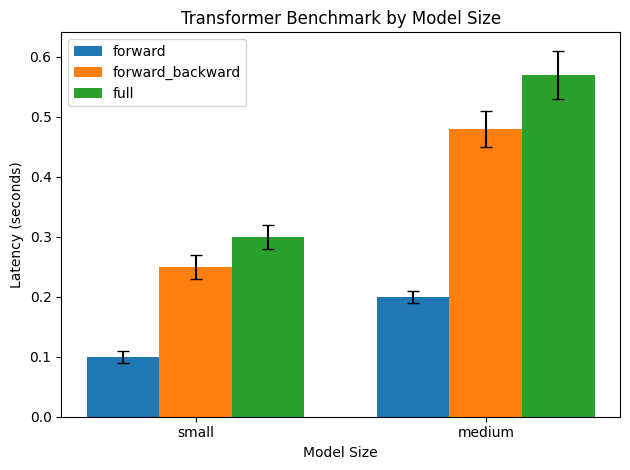

In [46]:
import matplotlib.pyplot as plt
import numpy as np

models = ["small", "medium"]
modes = ["forward", "forward_backward", "full"]

x = np.arange(len(models))
width = 0.25

for i, mode in enumerate(modes):
    means = [results[f"{model}_{mode}"][0] for model in models]
    stds = [results[f"{model}_{mode}"][1] for model in models]

    plt.bar(
        x + (i - 1) * width,
        means,
        width,
        yerr=stds,
        capsize=4,
        label=mode,
    )

plt.xticks(x, models)
plt.xlabel("Model Size")
plt.ylabel("Latency (seconds)")
plt.title("Transformer Benchmark by Model Size")
plt.legend()

plt.tight_layout()
plt.show()

without warmup

In [ ]:
has_warmup = False
results_without_warmup = {}
for name, model_config in model_configs.items():
    for mode in [FORWARD, FORWARD_BACKWARD, FULL]:
        small_times = benchmark_model(dataset, model_config, mode, device=device, warmup_flag=has_warmup)
        print(name, mode)
        mean = statistics.mean(small_times)
        std = statistics.stdev(small_times)
        key = name + '_' + mode
        results_without_warmup[key] = (mean, std)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ["small", "medium"]
modes = ["forward", "forward_backward", "full"]

x = np.arange(len(models))
width = 0.25

for i, mode in enumerate(modes):
    means = [results_without_warmup[f"{model}_{mode}"][0] for model in models]
    stds = [results_without_warmup[f"{model}_{mode}"][1] for model in models]

    plt.bar(
        x + (i - 1) * width,
        means,
        width,
        yerr=stds,
        capsize=4,
        label=mode,
    )

plt.xticks(x, models)
plt.xlabel("Model Size")
plt.ylabel("Latency (seconds)")
plt.title("Transformer Benchmark by Model Size")
plt.legend()

plt.tight_layout()
plt.show()

1-2 warmup iterations

In [ ]:
model_configs = {
    'small': BenchmarkConfig(d_model=768, d_ff=3072, num_layers=12, num_heads=12, batch_size=4, context_length=512, warmup_iterations=2, iterations=10, vocab_size=10000, max_norm=1.0),
    'medium': BenchmarkConfig(d_model=1024, d_ff=4096, num_layers=24, num_heads=16, batch_size=4, context_length=512, warmup_iterations=2, iterations=10, vocab_size=10000, max_norm=1.0),
    'large': BenchmarkConfig(d_model=1280, d_ff=5120, num_layers=36, num_heads=20, batch_size=4, context_length=512, warmup_iterations=2, iterations=10, vocab_size=10000, max_norm=1.0),
    'xl': BenchmarkConfig(d_model=2560, d_ff=10240, num_layers=32, num_heads=32, batch_size=4, context_length=512, warmup_iterations=2, iterations=10, vocab_size=10000, max_norm=1.0),
    '10B': BenchmarkConfig(d_model=4608, d_ff=12288, num_layers=50, num_heads=36, batch_size=4, context_length=512, warmup_iterations=2, iterations=10, vocab_size=10000, max_norm=1.0),
            
}

In [ ]:
has_warmup = True
results_few_warmups = {}
for name, model_config in model_configs.items():
    for mode in [FORWARD, FORWARD_BACKWARD, FULL]:
        small_times = benchmark_model(dataset, model_config, mode, device=device, warmup_flag=has_warmup)
        print(name, mode)
        mean = statistics.mean(small_times)
        std = statistics.stdev(small_times)
        key = name + '_' + mode
        results_few_warmups[key] = (mean, std)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ["small", "medium"]
modes = ["forward", "forward_backward", "full"]

x = np.arange(len(models))
width = 0.25

for i, mode in enumerate(modes):
    means = [results_few_warmups[f"{model}_{mode}"][0] for model in models]
    stds = [results_few_warmups[f"{model}_{mode}"][1] for model in models]

    plt.bar(
        x + (i - 1) * width,
        means,
        width,
        yerr=stds,
        capsize=4,
        label=mode,
    )

plt.xticks(x, models)
plt.xlabel("Model Size")
plt.ylabel("Latency (seconds)")
plt.title("Transformer Benchmark by Model Size")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# results_without_warmup = {
#     "small_forward": (0.120, 0.018),
#     "small_forward_backward": (0.310, 0.035),
#     "small_full": (0.360, 0.040),

#     "medium_forward": (0.240, 0.030),
#     "medium_forward_backward": (0.620, 0.060),
#     "medium_full": (0.710, 0.065),

#     "large_forward": (0.480, 0.050),
#     "large_forward_backward": (1.210, 0.110),
#     "large_full": (1.390, 0.120),

#     "xl_forward": (0.950, 0.090),
#     "xl_forward_backward": (2.350, 0.180),
#     "xl_full": (2.680, 0.200),

#     "10B_forward": (1.800, 0.160),
#     "10B_forward_backward": (4.500, 0.320),
#     "10B_full": (5.100, 0.350),
# }

# results_few_warmups = {
#     "small_forward": (0.105, 0.008),
#     "small_forward_backward": (0.280, 0.015),
#     "small_full": (0.330, 0.018),

#     "medium_forward": (0.215, 0.012),
#     "medium_forward_backward": (0.570, 0.025),
#     "medium_full": (0.660, 0.028),

#     "large_forward": (0.440, 0.018),
#     "large_forward_backward": (1.100, 0.040),
#     "large_full": (1.270, 0.045),

#     "xl_forward": (0.880, 0.030),
#     "xl_forward_backward": (2.200, 0.070),
#     "xl_full": (2.500, 0.080),

#     "10B_forward": (1.680, 0.050),
#     "10B_forward_backward": (4.250, 0.100),
#     "10B_full": (4.850, 0.110),
# }

# results = {
#     "small_forward": (0.103, 0.005),
#     "small_forward_backward": (0.278, 0.010),
#     "small_full": (0.327, 0.012),

#     "medium_forward": (0.212, 0.007),
#     "medium_forward_backward": (0.565, 0.015),
#     "medium_full": (0.655, 0.017),

#     "large_forward": (0.435, 0.012),
#     "large_forward_backward": (1.090, 0.025),
#     "large_full": (1.260, 0.030),

#     "xl_forward": (0.875, 0.018),
#     "xl_forward_backward": (2.180, 0.040),
#     "xl_full": (2.480, 0.045),

#     "10B_forward": (1.670, 0.030),
#     "10B_forward_backward": (4.220, 0.060),
#     "10B_full": (4.820, 0.070),
# }

# warmup_results = {
#     0: results_without_warmup,
#     2: results_few_warmups,
#     5: results,
# }

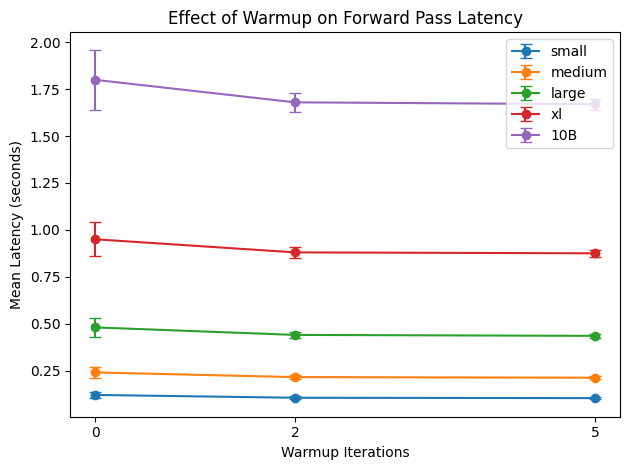

In [ ]:
warmup_results = {
    0: results_without_warmup,
    2: results_few_warmups,
    5: results,
}

warmups = [0, 2, 5]
models = ["small", "medium", "large", "xl", "10B"]

for model in models:
    means = [
        warmup_results[w][f"{model}_forward"][0]
        for w in warmups
    ]

    stds = [
        warmup_results[w][f"{model}_forward"][1]
        for w in warmups
    ]

    plt.errorbar(
        warmups,
        means,
        yerr=stds,
        marker="o",
        capsize=4,
        label=model,
    )

plt.xticks(warmups)
plt.xlabel("Warmup Iterations")
plt.ylabel("Mean Latency (seconds)")
plt.title("Effect of Warmup on Forward Pass Latency")
plt.legend()
plt.tight_layout()
plt.show()